BERT（TF/Keras）

split + Dataset + DataLoader

In [38]:
!pip -q install -U torch transformers scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score, classification_report,
    multilabel_confusion_matrix, precision_recall_fscore_support
)

import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup



建模 + 训练（multi-label BCEWithLogitsLoss）

In [39]:
DATA_PATH = r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv"
TEXT_COL = "title"
LABEL_COL = "classes_str"

df = pd.read_csv(DATA_PATH).dropna(subset=[TEXT_COL, LABEL_COL]).copy()
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

def parse_labels(s: str):
    # dataset_A_news_full_10500 的 classes_str 是用 ; 分隔的多标签
    labels = [t.strip() for t in str(s).split(";") if t.strip()]
    return sorted(set(labels))  # 去重，避免同一条重复标签

label_lists = df[LABEL_COL].apply(parse_labels).tolist()

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(label_lists).astype(np.float32)

class_names = list(mlb.classes_)
num_labels = len(class_names)

print("num_samples:", len(df))
print("num_labels:", num_labels)
print("labels:", class_names)
print("avg labels/sample:", float(Y.sum(axis=1).mean()))


num_samples: 10500
num_labels: 12
labels: ['Cognitive & Decision-Making', 'Creativity, Expression & Identity', 'Emotion, Motivation & Well-being', 'Health, Safety & Risk', 'Human Roles', 'Learning, Knowledge & Education', 'Routine, Lifestyle & Behavior', 'Sentiment (Positive / Negative Feelings)', 'Social Interaction & Relationships', 'Society, Ethics & Culture', 'Technology & Interaction', 'Work, Jobs & Economy']
avg labels/sample: 1.541428565979004


train/val/test split（8400 / 1050 / 1050）

In [40]:
X = df[TEXT_COL].values
y = Y

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42
)

print("train:", len(X_train), "val:", len(X_val), "test:", len(X_test))



train: 8400 val: 1050 test: 1050


Tokenizer + PyTorch Dataset/DataLoader

In [41]:
MODEL_CKPT = "bert-base-uncased"   # Dataset A 是英文标题，优先用英文模型
MAX_LEN = 64
BATCH_TRAIN = 16
BATCH_EVAL = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)
        self.labels = labels.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

train_ds = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = NewsDataset(X_val, y_val, tokenizer, MAX_LEN)
test_ds  = NewsDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_EVAL, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_EVAL, shuffle=False)


建模 + 训练（Multi-label BCEWithLogitsLoss）

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=num_labels,
    problem_type="multi_label_classification"
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = torch.nn.BCEWithLogitsLoss()

EPOCHS = 3
num_train_steps = EPOCHS * len(train_loader)
num_warmup_steps = int(0.1 * num_train_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_train_steps
)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}

        out = model(**inputs)
        loss = loss_fn(out.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += float(loss.item())

    print(f"Epoch {epoch+1}/{EPOCHS} - train loss: {total_loss/len(train_loader):.4f}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


device: cpu
Epoch 1/3 - train loss: 0.3346
Epoch 2/3 - train loss: 0.1245
Epoch 3/3 - train loss: 0.0738


预测概率函数（sigmoid）

In [43]:
def predict_probs(model, dataloader, device):
    model.eval()
    probs_all = []
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**inputs).logits
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.append(probs)
    return np.vstack(probs_all)

val 调阈值（最大化 micro-F1）→ test 输出 micro/macro/per-label

In [44]:
# 1) VAL: 调阈值，主优化 micro-F1（比赛主指标）
val_probs = predict_probs(model, val_loader, device)

best_thr, best_micro = 0.5, -1
for thr in np.arange(0.10, 0.91, 0.02):
    val_pred = (val_probs >= thr).astype(int)
    micro = f1_score(y_val, val_pred, average="micro", zero_division=0)
    if micro > best_micro:
        best_micro, best_thr = micro, thr

print(f"[VAL] Best threshold = {best_thr:.2f}, micro-F1 = {best_micro:.4f}")

# 2) TEST: 固定阈值，输出最终成绩
test_probs = predict_probs(model, test_loader, device)
test_pred = (test_probs >= best_thr).astype(int)

micro_f1 = f1_score(y_test, test_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)

print(f"[TEST] micro-F1 (PRIMARY) = {micro_f1:.4f}")
print(f"[TEST] macro-F1          = {macro_f1:.4f}\n")

print(classification_report(y_test, test_pred, target_names=class_names, digits=3, zero_division=0))

[VAL] Best threshold = 0.42, micro-F1 = 0.9730
[TEST] micro-F1 (PRIMARY) = 0.9678
[TEST] macro-F1          = 0.9529

                                          precision    recall  f1-score   support

             Cognitive & Decision-Making      0.965     0.921     0.943        89
       Creativity, Expression & Identity      0.988     0.964     0.976        83
        Emotion, Motivation & Well-being      0.938     0.703     0.804        64
                   Health, Safety & Risk      0.992     0.992     0.992       120
                             Human Roles      1.000     0.966     0.983       146
         Learning, Knowledge & Education      0.989     1.000     0.995       188
           Routine, Lifestyle & Behavior      0.993     0.944     0.968       142
Sentiment (Positive / Negative Feelings)      0.940     0.940     0.940       150
      Social Interaction & Relationships      0.905     0.848     0.876        79
               Society, Ethics & Culture      1.000     0.987 

per-label F1 可排序表（找“掉队标签”）

In [45]:
p, r, f1, s = precision_recall_fscore_support(
    y_test, test_pred, average=None, zero_division=0
)

df_label = pd.DataFrame({
    "label": class_names,
    "support": s,       # 每个标签真实为1的数量
    "precision": p,
    "recall": r,
    "f1": f1
}).sort_values(["f1", "support"], ascending=[True, True]).reset_index(drop=True)

df_label

,label,support,precision,recall,f1
0,"Emotion, Motivation & Well-being",64,0.937500,0.703125,0.803571
1,Social Interaction & Relationships,79,0.905405,0.848101,0.875817
2,Sentiment (Positive / Negative Feelings),150,0.940000,0.940000,0.940000
3,Cognitive & Decision-Making,89,0.964706,0.921348,0.942529
4,"Routine, Lifestyle & Behavior",142,0.992593,0.943662,0.967509
5,Technology & Interaction,183,0.972527,0.967213,0.969863
6,"Creativity, Expression & Identity",83,0.987654,0.963855,0.975610
7,Human Roles,146,1.000000,0.965753,0.982578
8,"Health, Safety & Risk",120,0.991667,0.991667,0.991667
9,"Society, Ethics & Culture",149,1.000000,0.986577,0.993243


visualization

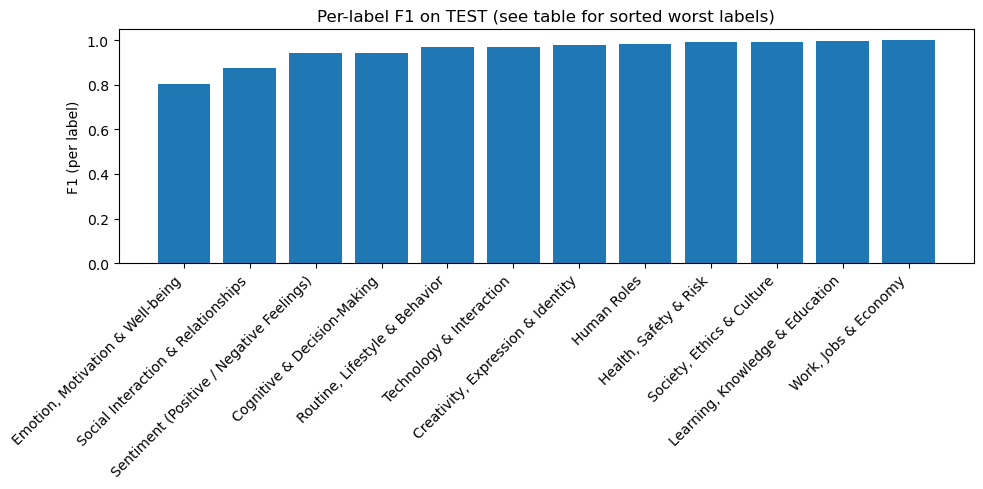

In [46]:
plt.figure(figsize=(10, 5))
plt.bar(df_label["label"], df_label["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 (per label)")
plt.title("Per-label F1 on TEST (see table for sorted worst labels)")
plt.tight_layout()
plt.show()

多标签混淆矩阵：每标签 2x2（TP/FP/FN/TN）+ 画任意标签

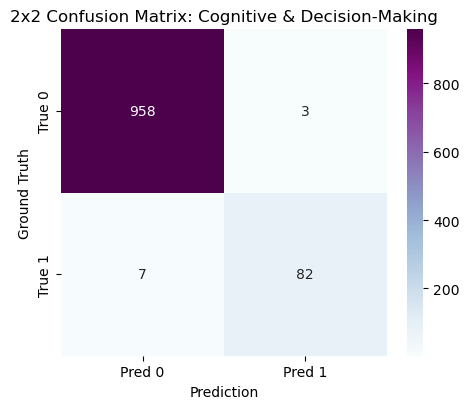

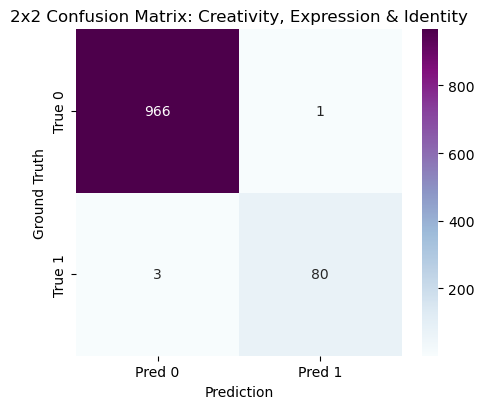

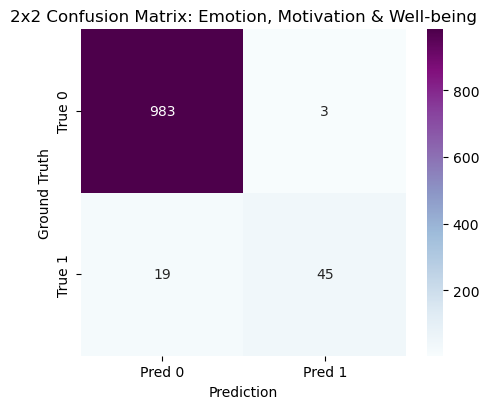

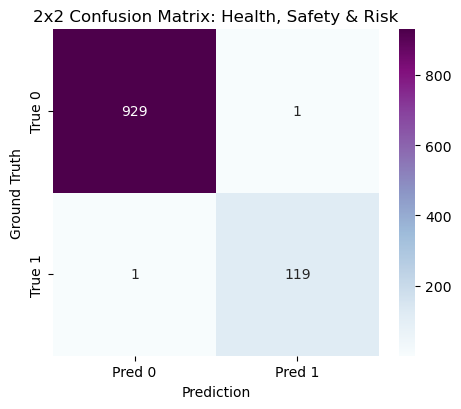

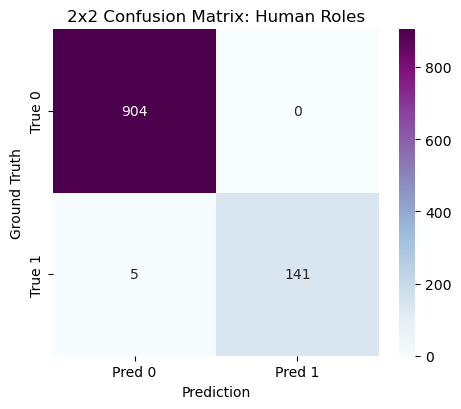

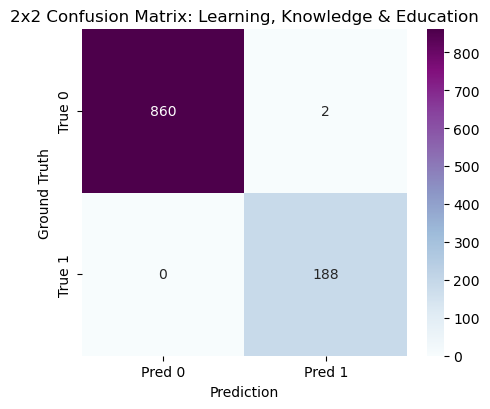

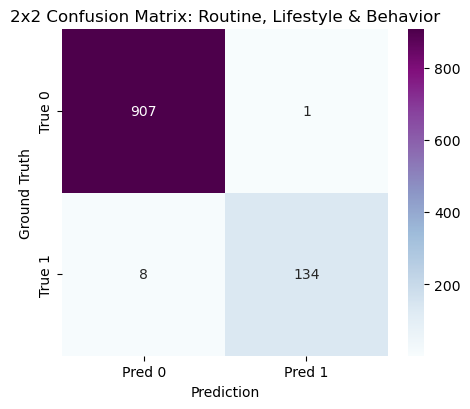

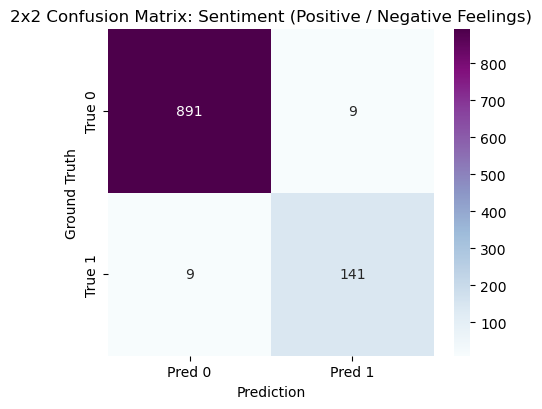

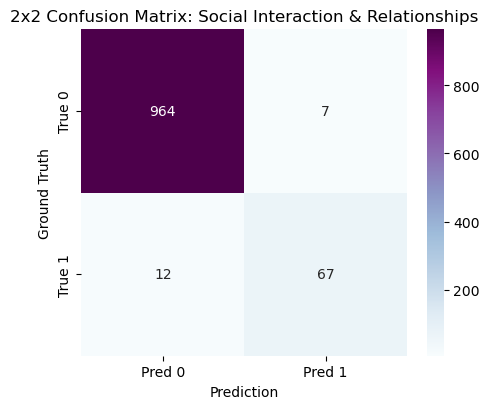

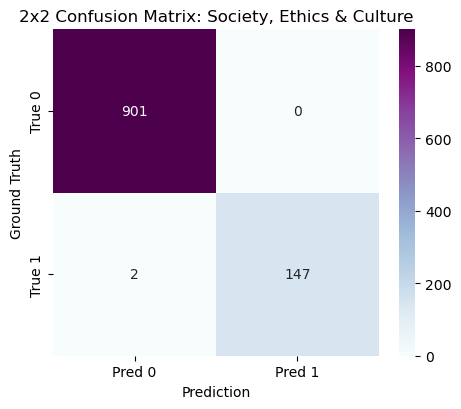

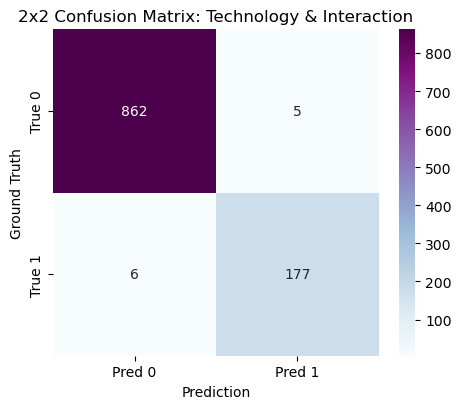

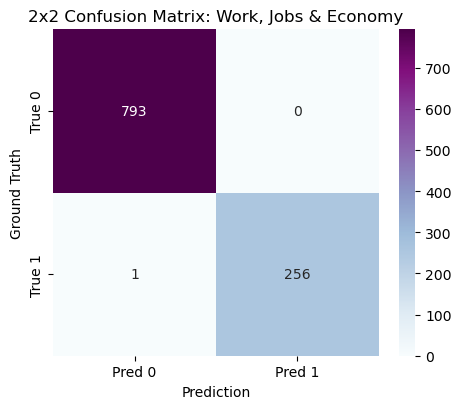

In [47]:
cms = multilabel_confusion_matrix(y_test, test_pred)

def plot_label_cm(label_idx):
    name = class_names[label_idx]
    tn, fp, fn, tp = cms[label_idx].ravel()
    mat = np.array([[tn, fp],
                    [fn, tp]])

    plt.figure(figsize=(4.8, 4.2))
    sns.heatmap(mat, annot=True, fmt="d", cmap="BuPu",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"2x2 Confusion Matrix: {name}")
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()

for i in range(len(class_names)):
    plot_label_cm(i)

输出“最容易漏判/误判”的标签（FN 高 / FP 高）

In [48]:
rows = []
for i, name in enumerate(class_names):
    tn, fp, fn, tp = cms[i].ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1_i      = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    rows.append({
        "label": name,
        "support_pos": int(tp + fn),  # 真实为1的数量
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "precision": precision,
        "recall": recall,
        "f1": f1_i
    })

df_err = pd.DataFrame(rows)

print("=== Most missed labels (high FN) => recall issue ===")
display(df_err.sort_values(["FN", "support_pos"], ascending=[False, False]).head(6))

print("=== Most over-predicted labels (high FP) => precision issue ===")
display(df_err.sort_values(["FP"], ascending=False).head(6))


=== Most missed labels (high FN) => recall issue ===


,label,support_pos,TP,FP,FN,TN,precision,recall,f1
2,"Emotion, Motivation & Well-being",64,45,3,19,983,0.937500,0.703125,0.803571
8,Social Interaction & Relationships,79,67,7,12,964,0.905405,0.848101,0.875817
7,Sentiment (Positive / Negative Feelings),150,141,9,9,891,0.940000,0.940000,0.940000
6,"Routine, Lifestyle & Behavior",142,134,1,8,907,0.992593,0.943662,0.967509
0,Cognitive & Decision-Making,89,82,3,7,958,0.964706,0.921348,0.942529
10,Technology & Interaction,183,177,5,6,862,0.972527,0.967213,0.969863


=== Most over-predicted labels (high FP) => precision issue ===


,label,support_pos,TP,FP,FN,TN,precision,recall,f1
7,Sentiment (Positive / Negative Feelings),150,141,9,9,891,0.940000,0.940000,0.940000
8,Social Interaction & Relationships,79,67,7,12,964,0.905405,0.848101,0.875817
10,Technology & Interaction,183,177,5,6,862,0.972527,0.967213,0.969863
0,Cognitive & Decision-Making,89,82,3,7,958,0.964706,0.921348,0.942529
2,"Emotion, Motivation & Well-being",64,45,3,19,983,0.937500,0.703125,0.803571
5,"Learning, Knowledge & Education",188,188,2,0,860,0.989474,1.000000,0.994709
